In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import numpy as np
import os
import math
from sklearn.metrics import mean_squared_error, f1_score, confusion_matrix

# -------------------------------------------------------------------------
# IMPORTACAO DE ARQUIVOS LOCAIS
# -------------------------------------------------------------------------
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

import sys
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

# Importação CRÍTICA
from mm_config_mealey import CONFIG 
from mm_dataset_mealey import Mavic3Dataset, get_mavic3_datasets 
from mm_transformer_mealey import MultiModalTransformer, NeuralMealyLayer


# =========================================================================
# CONFIGURAÇÕES
# -------------------------------------------------------------------------
DATA_ROOT = CONFIG['data_root']

MAX_GRADIENT_NORM = 1.0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {DEVICE}")

LOSS_WEIGHTS = {
    'pos': 1.0,
    'cls': 1.0,
    'temporal': CONFIG['temporal_loss_weight']
}
print(f"Pesos da Loss: {LOSS_WEIGHTS}")


# =========================================================================
# FUNÇÕES DE TREINAMENTO (CORRIGIDO PARA POSIÇÃO NORMALIZADA)
# =========================================================================
def train_epoch(model, dataloader, criterion_pos, criterion_cls, optimizer, weights, verbose=False):
    model.train()
    running_loss_pos, running_loss_cls, running_loss_temporal = 0.0, 0.0, 0.0
    total_valid_cls_samples, total_time_steps, total_time_steps_temporal = 0, 0, 0
    all_mealy_states_train = []

    for batch_idx, batch in enumerate(tqdm(dataloader, desc="Treinamento")):
        # B é o batch size, T é o comprimento máximo da sequência
        B, T = batch['image'].shape[:2] 
        prev_mealy_state = None
        
        # AJUSTE: Adicionando lista para predições de posições normalizadas
        all_pred_pos, all_pred_pos_norm, all_pred_class = [], [], []

        optimizer.zero_grad()
        
        # Loop sequencial RESTAURADO para manter o estado Mealy (GRU) entre os passos de tempo
        for t in range(T):
            # As entradas são forçadas a (B, 1, C, H, W) para T=1
            image_t = batch['image'][:, t].to(DEVICE).unsqueeze(1)
            lidar_360_t = batch['lidar_360'][:, t].to(DEVICE).unsqueeze(1)
            livox_avia_t = batch['livox_avia'][:, t].to(DEVICE).unsqueeze(1)
            radar_t = batch['radar'][:, t].to(DEVICE).unsqueeze(1)

            # O modelo recebe T=1 e retorna predições de T=1
            output = model(image_t, lidar_360_t, livox_avia_t, radar_t, prev_mealy_state)
            
            # pred_pos é (B, 3) (DENORMALIZADO) - Usado para Loss Temporal
            all_pred_pos.append(output['pred_pos']) 
            # NOVO: pred_pos_norm é (B, 3) (NORMALIZADO) - Usado para Loss Posição
            all_pred_pos_norm.append(output['pred_pos_norm'])
            
            # pred_class_seq é (B, 1, 1). Reduzimos para (B, 1) para concatenar.
            all_pred_class.append(output['pred_class_seq'].squeeze(1)) 
            
            # Atualiza o estado Mealy para o próximo passo de tempo
            prev_mealy_state = output['final_mealy_state']
            all_mealy_states_train.append(prev_mealy_state.detach().cpu().numpy())

        # Flatten predictions para cálculo da Loss: (B*T, D)
        
        # Predições:
        pred_pos_flat = torch.cat(all_pred_pos, dim=0) # (B*T, 3) - DENORMALIZADO
        pred_pos_norm_flat = torch.cat(all_pred_pos_norm, dim=0) # (B*T, 3) - NORMALIZADO
        pred_class_flat = torch.cat(all_pred_class, dim=0) # (B*T, 1)
        
        # Ground Truth:
        gt_pos_t = batch['gt_pos'].to(DEVICE) # (B, T, 3)
        gt_class_flat = batch['gt_class'].reshape(B*T).to(DEVICE)

        # CORREÇÃO CRÍTICA: Normaliza o Ground Truth
        pos_mean = model.pos_mean.to(DEVICE)
        pos_std = model.pos_std.to(DEVICE)
        gt_pos_norm = (gt_pos_t - pos_mean) / pos_std
        gt_pos_norm_flat = gt_pos_norm.reshape(B*T, -1) # (B*T, 3)
        
        # Loss posição: AGORA USA A VERSÃO NORMALIZADA
        loss_pos = criterion_pos(pred_pos_norm_flat, gt_pos_norm_flat)
        running_loss_pos += loss_pos.item() * (B*T)
        total_time_steps += (B*T)

        # Loss classificação
        valid_mask = gt_class_flat != -1
        if valid_mask.any():
            valid_gt_class = gt_class_flat[valid_mask].float().unsqueeze(1) 
            valid_pred_class = pred_class_flat[valid_mask]
            loss_cls = criterion_cls(valid_pred_class, valid_gt_class)
            running_loss_cls += loss_cls.item() * valid_gt_class.size(0)
            total_valid_cls_samples += valid_gt_class.size(0)
        else:
            loss_cls = torch.tensor(0.0).to(DEVICE)

        # Loss temporal (smoothness): USA A VERSÃO DENORMALIZADA
        # Recria as sequências a partir das predições concatenadas para o cálculo do delta
        pred_seq = pred_pos_flat.reshape(B, T, 3) 
        gt_seq = gt_pos_t # (B, T, 3) - Denormalizado
        
        if T > 1:
            pred_delta = pred_seq[:,1:,:] - pred_seq[:,:-1,:]
            gt_delta = gt_seq[:,1:,:] - gt_seq[:,:-1,:]
            loss_temporal = torch.mean((gt_delta - pred_delta)**2)
            running_loss_temporal += loss_temporal.item() * (B*(T-1))
            total_time_steps_temporal += B*(T-1)
        else:
            loss_temporal = torch.tensor(0.0).to(DEVICE)

        # Combina perdas
        total_loss = (weights['pos']*loss_pos) + (weights['cls']*loss_cls) + (weights['temporal']*loss_temporal)
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRADIENT_NORM)
        optimizer.step()

        if verbose:
            print(f"[Batch {batch_idx+1}/{len(dataloader)}] Loss Pos: {loss_pos.item():.4f}, "
                  f"Cls: {loss_cls.item():.4f}, Temporal: {loss_temporal.item():.4f}")

    # Médias por época
    avg_pos = running_loss_pos / total_time_steps
    avg_cls = running_loss_cls / (total_valid_cls_samples if total_valid_cls_samples>0 else 1)
    avg_temporal = running_loss_temporal / (total_time_steps_temporal if total_time_steps_temporal > 0 else 1)
    return avg_pos, avg_cls, avg_temporal, all_mealy_states_train


def validate_epoch(model, dataloader, criterion_pos, criterion_cls):
    model.eval()
    val_loss_pos, val_loss_cls, val_loss_temporal = 0.0, 0.0, 0.0
    correct_cls, total_cls_samples = 0, 0
    total_time_steps, total_time_steps_temporal = 0, 0
    all_mealy_states_val = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validação"):
            B, T = batch['image'].shape[:2]
            prev_mealy_state = None
            
            # AJUSTE: Adicionando lista para predições de posições normalizadas
            all_pred_pos, all_pred_pos_norm, all_pred_class = [], [], []

            # Loop sequencial RESTAURADO
            for t in range(T):
                image_t = batch['image'][:, t].to(DEVICE).unsqueeze(1)
                lidar_360_t = batch['lidar_360'][:, t].to(DEVICE).unsqueeze(1)
                livox_avia_t = batch['livox_avia'][:, t].to(DEVICE).unsqueeze(1)
                radar_t = batch['radar'][:, t].to(DEVICE).unsqueeze(1)

                output = model(image_t, lidar_360_t, livox_avia_t, radar_t, prev_mealy_state)
                
                prev_mealy_state = output['final_mealy_state']
                all_mealy_states_val.append(prev_mealy_state.detach().cpu().numpy())

                all_pred_pos.append(output['pred_pos']) # Denormalizado (Para Loss Temporal)
                all_pred_pos_norm.append(output['pred_pos_norm']) # NOVO: Normalizado (Para Loss Pos)
                all_pred_class.append(output['pred_class_seq'].squeeze(1)) # (B, 1)

            # Flatten e ground truth
            pred_pos_flat = torch.cat(all_pred_pos, dim=0) # Denormalizado
            pred_pos_norm_flat = torch.cat(all_pred_pos_norm, dim=0) # NOVO: Normalizado
            pred_class_flat = torch.cat(all_pred_class, dim=0)
            
            gt_pos_t = batch['gt_pos'].to(DEVICE)
            gt_class_flat = batch['gt_class'].reshape(B*T).to(DEVICE)
            
            # CORREÇÃO CRÍTICA: Normaliza o Ground Truth
            pos_mean = model.pos_mean.to(DEVICE)
            pos_std = model.pos_std.to(DEVICE)
            gt_pos_norm = (gt_pos_t - pos_mean) / pos_std
            gt_pos_norm_flat = gt_pos_norm.reshape(B*T, -1)
            
            # Loss Posição: AGORA USA A VERSÃO NORMALIZADA
            loss_pos = criterion_pos(pred_pos_norm_flat, gt_pos_norm_flat)
            val_loss_pos += loss_pos.item()*(B*T)
            total_time_steps += B*T

            # Loss Classificação e Acurácia
            valid_mask = gt_class_flat != -1
            if valid_mask.any():
                valid_gt_class = gt_class_flat[valid_mask].float().unsqueeze(1)
                valid_pred_class = pred_class_flat[valid_mask]
                loss_cls = criterion_cls(valid_pred_class, valid_gt_class)
                val_loss_cls += loss_cls.item()*valid_gt_class.size(0)

                predicted = (valid_pred_class>0).long().squeeze(1)
                if predicted.ndim > 1: # Garante shape (N_valid)
                    predicted = predicted.squeeze(1) 
                correct_cls += (predicted == gt_class_flat[valid_mask]).sum().item()
                total_cls_samples += valid_gt_class.size(0)

            # Loss temporal: USA A VERSÃO DENORMALIZADA
            pred_seq = pred_pos_flat.reshape(B, T, 3)
            gt_seq = gt_pos_t
            
            if T > 1:
                pred_delta = pred_seq[:,1:,:] - pred_seq[:,:-1,:]
                gt_delta = gt_seq[:,1:,:] - gt_seq[:,:-1,:]
                loss_temporal = torch.mean((gt_delta - pred_delta)**2)
                val_loss_temporal += loss_temporal.item() * (B*(T-1))
                total_time_steps_temporal += B*(T-1)


    avg_pos = val_loss_pos / total_time_steps
    avg_cls = val_loss_cls / (total_cls_samples if total_cls_samples>0 else 1)
    avg_temporal = val_loss_temporal / (total_time_steps_temporal if total_time_steps_temporal > 0 else 1)
    accuracy_cls = (correct_cls / total_cls_samples)*100 if total_cls_samples>0 else 0.0

    print(f"[Validação] Loss Pos: {avg_pos:.4f}, Cls: {avg_cls:.4f}, Temporal: {avg_temporal:.4f}, Accuracy: {accuracy_cls:.2f}%")
    return avg_pos, avg_cls, avg_temporal, accuracy_cls, all_mealy_states_val


# =========================================================================
# TESTE FINAL (FLUXO SEQUENCIAL RESTAURADO) - NENHUMA MUDANÇA NECESSÁRIA
# =========================================================================
def test_pipeline(model, dataloader):
    model.eval()
    all_gt_pos, all_pred_pos, all_gt_class, all_pred_class, all_mealy_states_test = [], [], [], [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Teste"):
            B, T = batch['image'].shape[:2]
            prev_mealy_state = None

            for t in range(T):
                image_t = batch['image'][:, t].to(DEVICE).unsqueeze(1)
                lidar_360_t = batch['lidar_360'][:, t].to(DEVICE).unsqueeze(1)
                livox_avia_t = batch['livox_avia'][:, t].to(DEVICE).unsqueeze(1)
                radar_t = batch['radar'][:, t].to(DEVICE).unsqueeze(1)

                output = model(image_t, lidar_360_t, livox_avia_t, radar_t, prev_mealy_state)
                
                prev_mealy_state = output['final_mealy_state']
                all_mealy_states_test.append(prev_mealy_state.detach().cpu().numpy())

                # Coleta: O teste usa a posição DENORMALIZADA para o RMSE
                all_gt_pos.append(batch['gt_pos'][:, t, :].cpu().numpy())
                all_pred_pos.append(output['pred_pos'].cpu().numpy())
                all_gt_class.append(batch['gt_class'][:, t].cpu().numpy())
                
                # Predição binária de classe
                pred_class_logits = output['pred_class_seq'].squeeze(1).cpu().numpy()
                all_pred_class.append((pred_class_logits > 0).astype(int))

    all_gt_pos = np.concatenate(all_gt_pos, axis=0)
    all_pred_pos = np.concatenate(all_pred_pos, axis=0)
    all_gt_class = np.concatenate(all_gt_class, axis=0)
    all_pred_class = np.concatenate(all_pred_class, axis=0)
    
    if all_pred_class.ndim > 1 and all_pred_class.shape[1] == 1:
        all_pred_class = all_pred_class.squeeze(1)

    # Remove amostras de classe inválidas para as métricas de classificação
    valid_mask_cls = all_gt_class != -1
    valid_gt_class = all_gt_class[valid_mask_cls]
    valid_pred_class = all_pred_class[valid_mask_cls]

    rmse_pos = math.sqrt(mean_squared_error(all_gt_pos, all_pred_pos))
    smoothness_error = np.mean(np.linalg.norm(np.diff(all_pred_pos, axis=0) - np.diff(all_gt_pos, axis=0), axis=1))
    
    # Se nao houver amostras validas, evita erros
    if valid_gt_class.size > 0:
        f1_cls = f1_score(valid_gt_class, valid_pred_class, average='weighted', zero_division=0)
        conf_matrix = confusion_matrix(valid_gt_class, valid_pred_class)
    else:
        f1_cls = 0.0
        conf_matrix = np.array([[0,0],[0,0]]) 


    print(f"=== Teste Final ===")
    print(f"RMSE Pos: {rmse_pos:.4f}")
    print(f"Erro Suavidade Temporal: {smoothness_error:.4f}")
    print(f"F1-Score Cls: {f1_cls:.4f}")
    print("Matriz de Confusão (apenas classes válidas):")
    print(conf_matrix)
    print(f"Total de estados Mealy registrados: {len(all_mealy_states_test)}")

    return {
        'rmse_pos': rmse_pos,
        'smoothness_error': smoothness_error,
        'f1_score_cls': f1_cls,
        'conf_matrix': conf_matrix,
        'mealy_states': all_mealy_states_test
    }


# =========================================================================
# MAIN (AJUSTADO) - NENHUMA MUDANÇA NECESSÁRIA
# =========================================================================
def main_adjusted():
    try:
        datasets = get_mavic3_datasets(DATA_ROOT, CONFIG)
        train_dataset, val_dataset, test_dataset = datasets['train'], datasets['val'], datasets['test']

        # AJUSTE CRÍTICO: Removendo o collate_fn customizado, pois as PCLs agora são de tamanho fixo (9).
        train_loader = DataLoader(
            train_dataset, 
            batch_size=CONFIG["batch_size"], 
            shuffle=True, 
            num_workers=CONFIG["num_workers"], 
            pin_memory=True
        )
        val_loader = DataLoader(
            val_dataset, 
            batch_size=CONFIG["batch_size"], 
            shuffle=False, 
            num_workers=CONFIG["num_workers"], 
            pin_memory=True
        )
        test_loader = DataLoader(
            test_dataset, 
            batch_size=CONFIG["batch_size"], 
            shuffle=False, 
            num_workers=CONFIG["num_workers"], 
            pin_memory=True
        )

    except Exception as e:
        print(f"Erro ao carregar datasets: {e}")
        return

    # =========================================================================
    # CORREÇÃO CRÍTICA 1: Extrair e passar as estatísticas de normalização
    # =========================================================================
    normalizer = train_dataset.normalizer
    
    pos_mean_t = torch.from_numpy(normalizer.mean.squeeze()).float()
    pos_std_t = torch.from_numpy(normalizer.std.squeeze()).float()

    model = MultiModalTransformer(
        CONFIG,
        pos_mean=pos_mean_t,
        pos_std=pos_std_t
    ).to(DEVICE)
    # =========================================================================
    
    # =========================================================================
    # CORREÇÕES CRÍTICAS 2 & 3: Ajuste de Learning Rate e Loss Weights
    # =========================================================================
    # Reduzindo o Learning Rate para 1/10
    NEW_LR = CONFIG["learning_rate"] 
    print(f"Learning Rate ajustada para: {NEW_LR:.1e}")

    # Reduzindo o peso da Loss de Posição de 1.0 para 0.1 (ou 0.01 se 0.1 não funcionar)
    LOSS_WEIGHTS_ADJUSTED = {
        'pos': 0.1, 
        'cls': 1.0,
        'temporal': CONFIG['temporal_loss_weight']
    }
    print(f"Pesos da Loss ajustados (Pos: {LOSS_WEIGHTS_ADJUSTED['pos']}): {LOSS_WEIGHTS_ADJUSTED}")
    
    # criterion_pos agora opera em tensores normalizados
    criterion_pos = nn.MSELoss()
    criterion_cls = nn.BCEWithLogitsLoss()
    
    # Usando o novo Learning Rate
    optimizer = torch.optim.AdamW(model.parameters(), lr=NEW_LR, weight_decay=1e-4)
    
    # O scheduler também deve usar o novo max_lr
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=NEW_LR * 5, 
        steps_per_epoch=len(train_loader), 
        epochs=CONFIG["epochs"]
    )
    # =========================================================================


    best_val_loss = float('inf')
    model_path = 'best_mm_transformer_mealey_model.pth'

    for epoch in range(CONFIG["epochs"]):
        print(f"\n=== Época {epoch+1}/{CONFIG['epochs']} ===")
        # Passando os pesos ajustados para o treino
        train_loss_pos, train_loss_cls, train_loss_temporal, _ = train_epoch(
            model, train_loader, criterion_pos, criterion_cls, optimizer, LOSS_WEIGHTS_ADJUSTED, verbose=False
        )
        print(f"[Treino] Pos: {train_loss_pos:.4f}, Cls: {train_loss_cls:.4f}, Temporal: {train_loss_temporal:.4f}")

        val_loss_pos, val_loss_cls, val_loss_temporal, val_acc_cls, _ = validate_epoch(model, val_loader, criterion_pos, criterion_cls)
        
        # Usando os pesos ajustados para o cálculo da Loss total
        total_val_loss = LOSS_WEIGHTS_ADJUSTED['pos']*val_loss_pos + LOSS_WEIGHTS_ADJUSTED['cls']*val_loss_cls + LOSS_WEIGHTS_ADJUSTED['temporal']*val_loss_temporal

        if total_val_loss < best_val_loss:
            best_val_loss = total_val_loss
            torch.save(model.state_dict(), model_path)
            print(f"Novo melhor modelo salvo com Loss total: {best_val_loss:.4f}")

        scheduler.step()

    # Teste final
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    test_results = test_pipeline(model, test_loader)
    print("Número de estados Mealy registrados no teste:", len(test_results['mealy_states']))


if __name__ == "__main__":
    main_adjusted()

Usando dispositivo: cpu
Pesos da Loss: {'pos': 1.0, 'cls': 1.0, 'temporal': 0.5}

Divisao do Dataset (Total: 833 amostras):
 - Treino: 665
 - Validacao: 84
 - Teste: 84


Pre-carregando GT para normalização: 100%|██████████| 665/665 [00:00<00:00, 6457.53it/s]

Normalizador de Posição inicializado. Média: 6.7959, Std: 4.6079
Dataset inicializado com 665 amostras.
Dataset inicializado com 84 amostras.
Dataset inicializado com 84 amostras.


Learning Rate ajustada para: 1.0e-07
Pesos da Loss ajustados (Pos: 0.1): {'pos': 0.1, 'cls': 1.0, 'temporal': 0.5}

=== Época 1/10 ===


Treinamento:   0%|          | 0/9 [00:00<?, ?it/s]c:\Users\Micro\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Treinamento: 100%|██████████| 9/9 [00:35<00:00,  3.94s/it]


...

[Treino] Pos: 2.2175, Cls: 0.6932, Temporal: 1.9698


Validação: 100%|██████████| 1/1 [00:07<00:00,  7.65s/it]


[Validação] Loss Pos: 2.0921, Cls: 0.7259, Temporal: 1.8613, Accuracy: 0.00%


Teste: 100%|██████████| 1/1 [00:07<00:00,  7.60s/it]

=== Teste Final ===
RMSE Pos: 7.4626
Erro Suavidade Temporal: 2.1352
F1-Score Cls: 0.9404
Matriz de Confusão (apenas classes válidas):
[[ 0  0]
 [ 9 71]]
Total de estados Mealy registrados: 10
Número de estados Mealy registrados no teste: 10


# Teste

Usando dispositivo: cpu

--- Recarregando Dataset e Modelo para Análise de Teste ---

Divisao do Dataset (Total: 833 amostras):
 - Treino: 665
 - Validacao: 84
 - Teste: 84


Pre-carregando GT para normalização: 100%|██████████| 665/665 [00:00<00:00, 1760.80it/s]


Normalizador de Posição inicializado. Média: 6.7959, Std: 4.6079
Dataset inicializado com 665 amostras.
Dataset inicializado com 84 amostras.
Dataset inicializado com 84 amostras.
Modelo e Dataset de Teste carregados com sucesso.


Análise de Teste (Sequencial):   0%|          | 0/8 [00:00<?, ?it/s]c:\Users\Micro\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


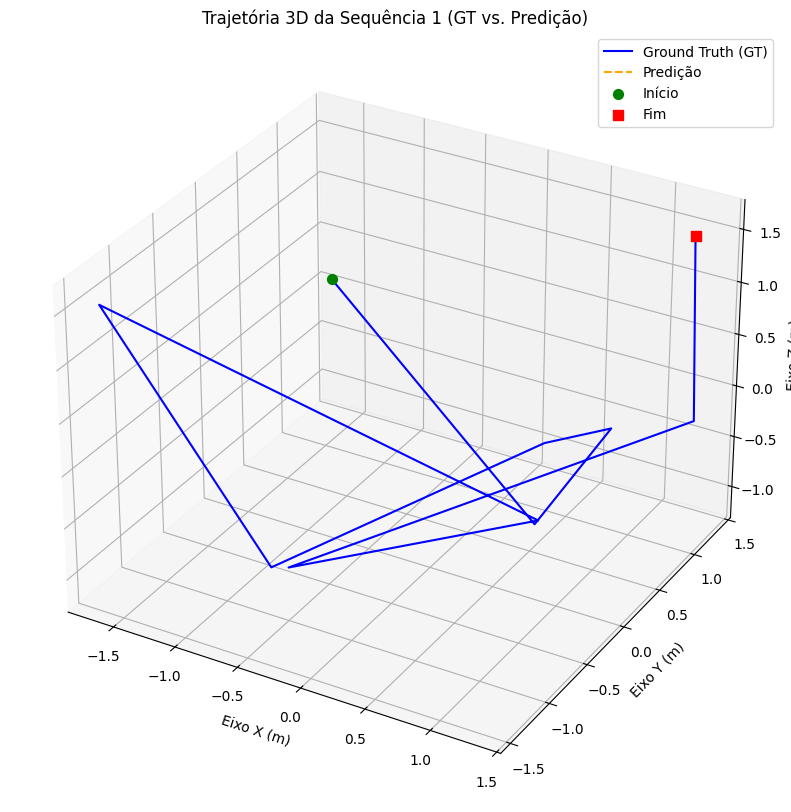

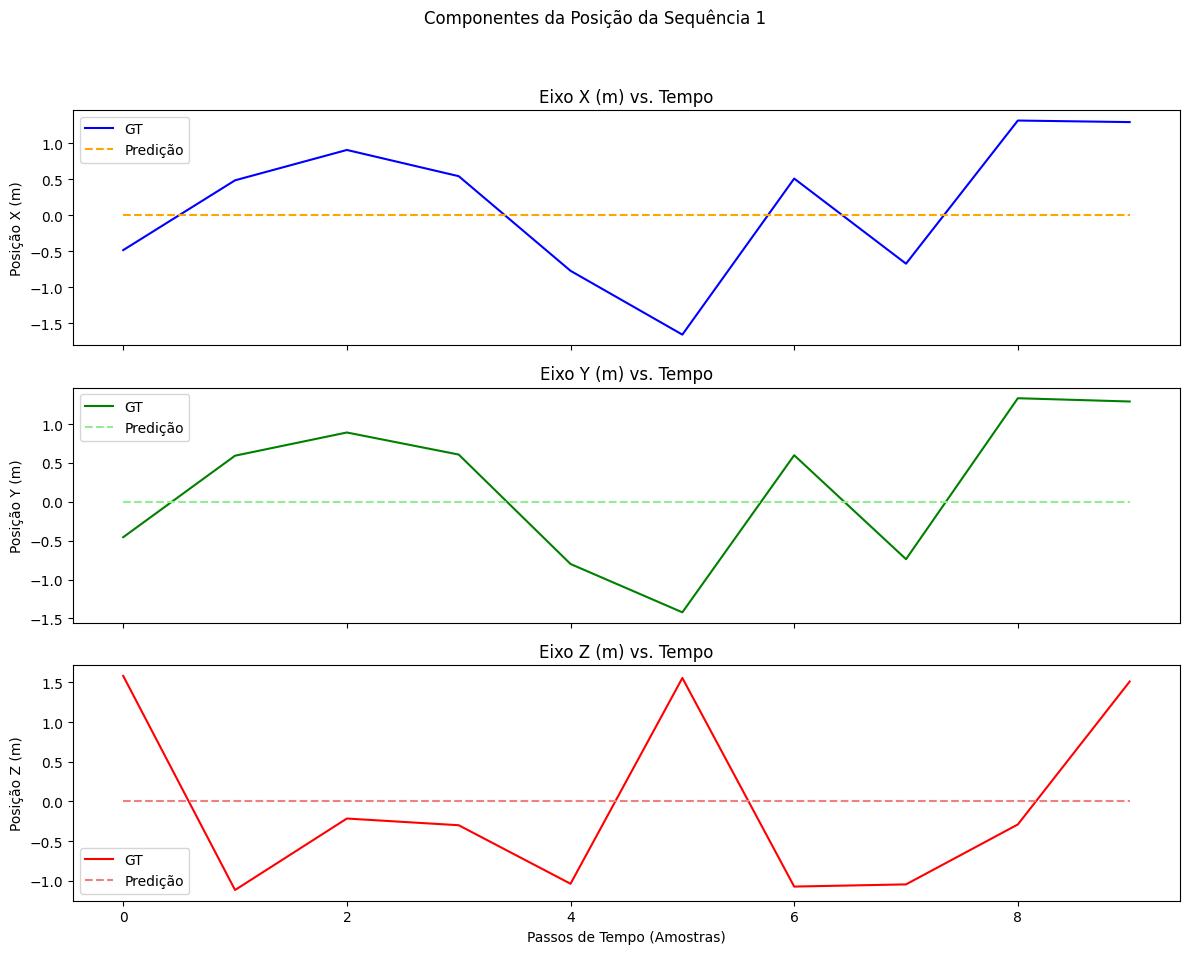

Análise de Teste (Sequencial):  12%|█▎        | 1/8 [00:00<00:06,  1.02it/s]

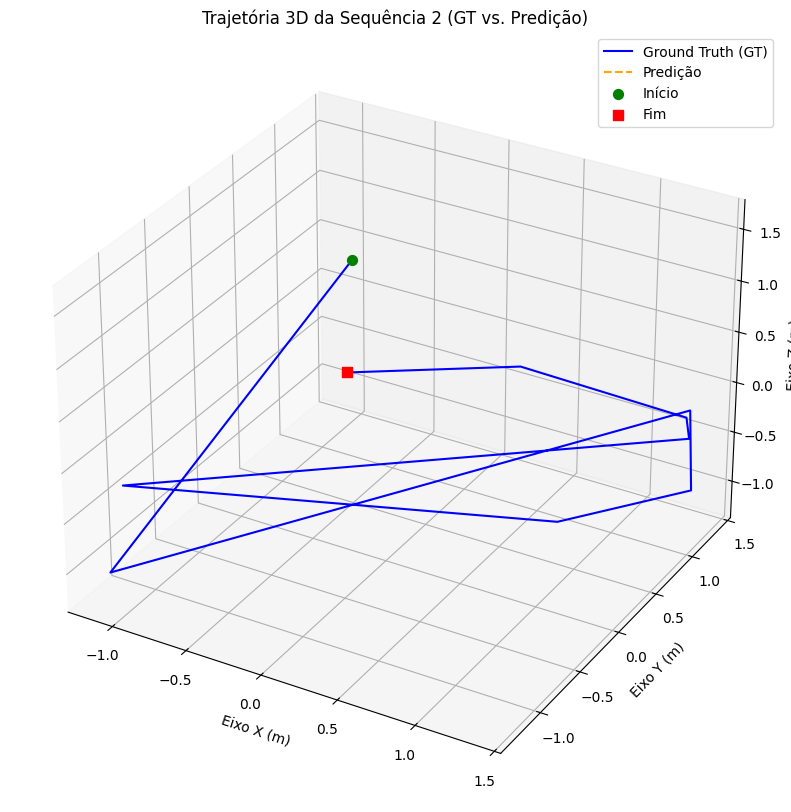

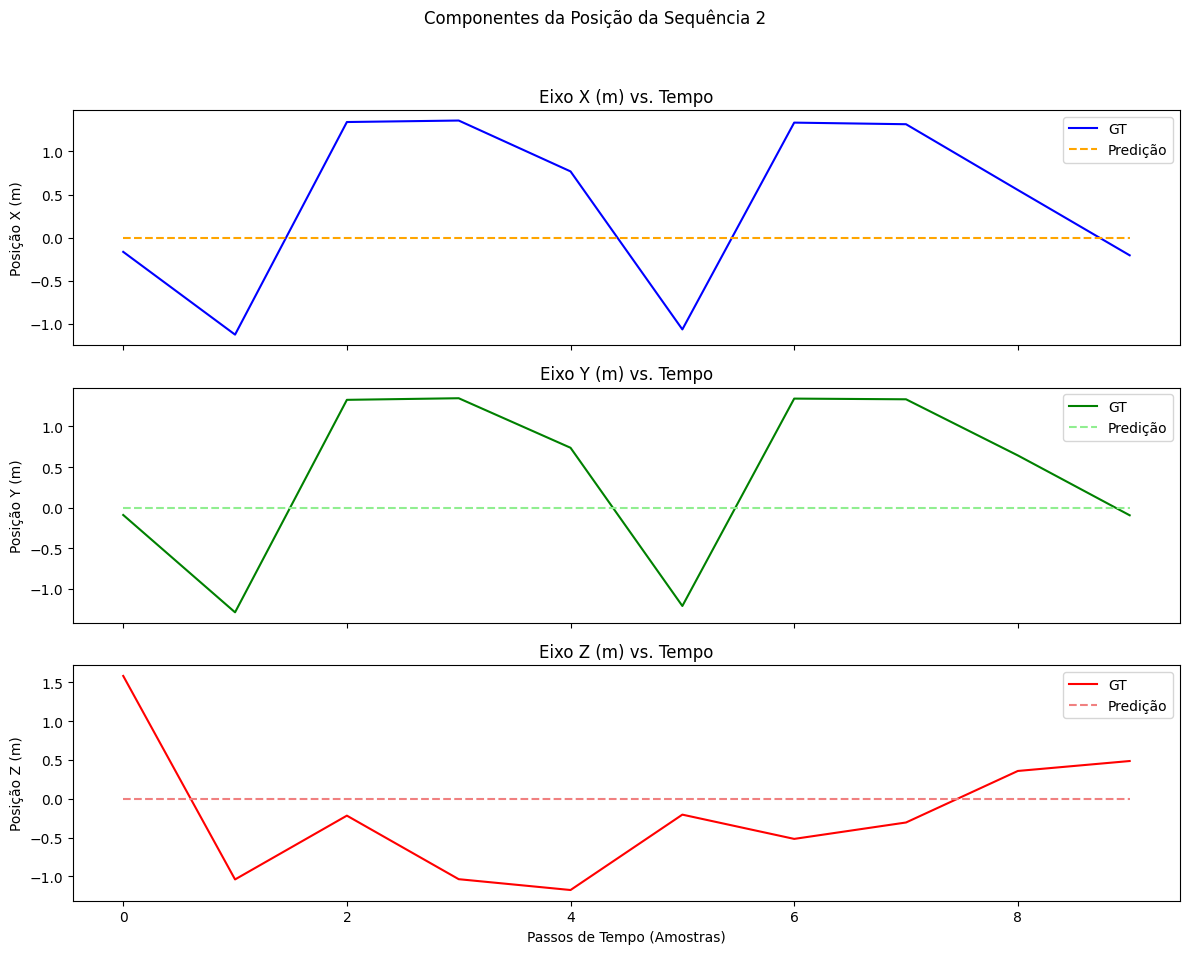

Análise de Teste (Sequencial):  25%|██▌       | 2/8 [00:01<00:05,  1.08it/s]

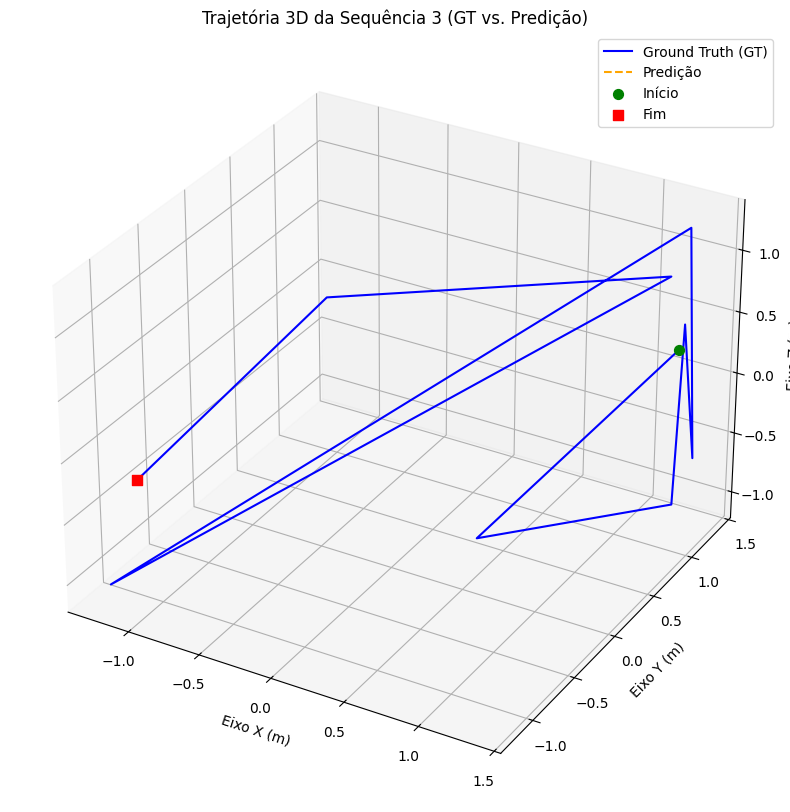

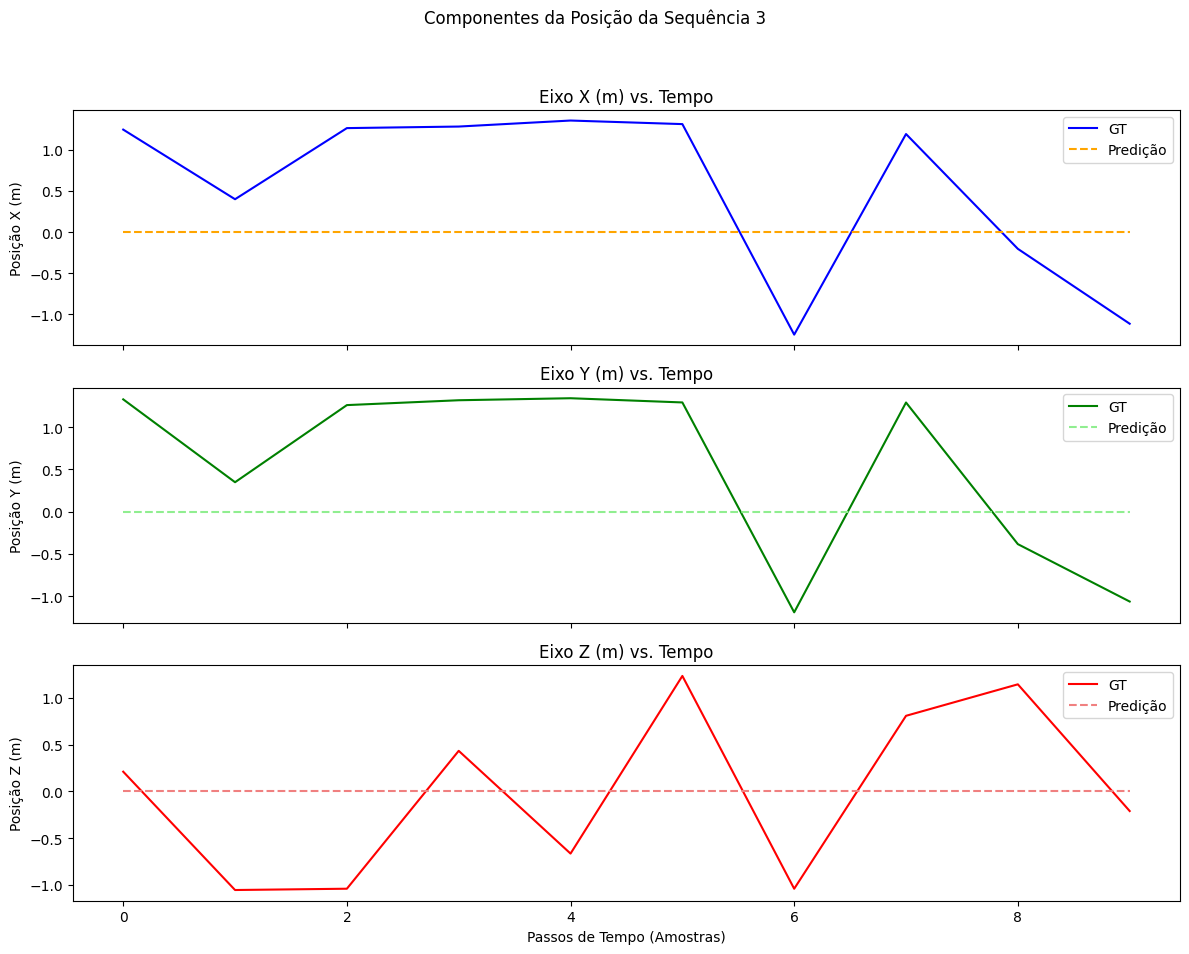

Análise de Teste (Sequencial): 100%|██████████| 8/8 [00:05<00:00,  1.42it/s]

=== Análise de Teste Final ===
RMSE Pos: 1.0011
Erro Suavidade Temporal: 2.1658
F1-Score Cls: 0.9404
Matriz de Confusão (apenas classes válidas):
[[ 0  0]
 [ 9 71]]
Total de estados Mealy registrados: 80


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import numpy as np
import os
import math
from sklearn.metrics import mean_squared_error, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Import necessário para 3D

# Seus imports locais, que devem garantir que CONFIG, MultiModalTransformer, etc., estão definidos
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

import sys
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

# Importação CRÍTICA
from mm_config_mealey import CONFIG 
from mm_dataset_mealey import Mavic3Dataset, get_mavic3_datasets 
from mm_transformer_mealey import MultiModalTransformer, NeuralMealyLayer

# =========================================================================
# CONFIGURAÇÕES (Re-definição/Acesso)
# =========================================================================
DATA_ROOT = CONFIG['data_root']
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {DEVICE}")


# =========================================================================
# FUNÇÕES DE PLOTAGEM (AJUSTADAS para Sequência Única)
# =========================================================================
def plot_trajectories_3d(gt_pos, pred_pos, sequence_idx):
    """ Plota a trajetória 3D de uma única sequência."""
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # GT
    ax.plot(gt_pos[:, 0], gt_pos[:, 1], gt_pos[:, 2], color='blue', label='Ground Truth (GT)')
    # Predição
    ax.plot(pred_pos[:, 0], pred_pos[:, 1], pred_pos[:, 2], color='orange', linestyle='--', label='Predição')
    
    # Pontos de Início e Fim
    ax.scatter(gt_pos[0, 0], gt_pos[0, 1], gt_pos[0, 2], color='green', marker='o', s=50, label='Início')
    ax.scatter(gt_pos[-1, 0], gt_pos[-1, 1], gt_pos[-1, 2], color='red', marker='s', s=50, label='Fim')

    ax.set_xlabel('Eixo X (m)')
    ax.set_ylabel('Eixo Y (m)')
    ax.set_zlabel('Eixo Z (m)')
    ax.set_title(f'Trajetória 3D da Sequência {sequence_idx} (GT vs. Predição)')
    ax.legend()
    plt.show()

def plot_trajectories_2d(gt_pos, pred_pos, sequence_idx):
    """ Plota as componentes X, Y, Z vs. Tempo de uma única sequência."""
    T = len(gt_pos)
    time_steps = np.arange(T)

    fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    
    # Componente X
    axs[0].plot(time_steps, gt_pos[:, 0], label='GT', color='blue')
    axs[0].plot(time_steps, pred_pos[:, 0], label='Predição', color='orange', linestyle='--')
    axs[0].set_title('Eixo X (m) vs. Tempo')
    axs[0].set_ylabel('Posição X (m)')
    axs[0].legend()

    # Componente Y
    axs[1].plot(time_steps, gt_pos[:, 1], label='GT', color='green')
    axs[1].plot(time_steps, pred_pos[:, 1], label='Predição', color='lightgreen', linestyle='--')
    axs[1].set_title('Eixo Y (m) vs. Tempo')
    axs[1].set_ylabel('Posição Y (m)')
    axs[1].legend()
    
    # Componente Z
    axs[2].plot(time_steps, gt_pos[:, 2], label='GT', color='red')
    axs[2].plot(time_steps, pred_pos[:, 2], label='Predição', color='lightcoral', linestyle='--')
    axs[2].set_title('Eixo Z (m) vs. Tempo')
    axs[2].set_xlabel('Passos de Tempo (Amostras)')
    axs[2].set_ylabel('Posição Z (m)')
    axs[2].legend()

    fig.suptitle(f'Componentes da Posição da Sequência {sequence_idx}')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# =========================================================================
# FUNÇÃO DE TESTE/ANÁLISE (AJUSTADA para Iterar sobre Dataset)
# =========================================================================
def enhanced_test_analysis_sequential(model, test_dataset, device, plot_sequences=True):
    """
    Executa o pipeline de teste em modo sequencial, uma sequência de cada vez (B=1).
    Isso é necessário para plotagem e para garantir o uso correto do estado Mealy.
    """
    model.eval()
    all_gt_pos, all_pred_pos, all_gt_class, all_pred_class, all_mealy_states_test = [], [], [], [], []

    # Cria um DataLoader com batch_size=1, crucial para processar sequências individuais
    sequence_loader = DataLoader(
        test_dataset, 
        batch_size=1, 
        shuffle=False, 
        num_workers=0, # Reduzido para B=1
        pin_memory=True
    )
    
    with torch.no_grad():
        for sequence_idx, batch in enumerate(tqdm(sequence_loader, desc="Análise de Teste (Sequencial)")):
            
            # O Batch size é 1 (B=1)
            B, T = batch['image'].shape[:2]
            
            # Arrays para a sequência atual
            seq_gt_pos, seq_pred_pos = [], []
            prev_mealy_state = None

            # Loop sequencial sobre T (Time Steps)
            for t in range(T):
                # Entrada (1, 1, ...)
                image_t = batch['image'][:, t].to(device).unsqueeze(1)
                lidar_360_t = batch['lidar_360'][:, t].to(device).unsqueeze(1)
                livox_avia_t = batch['livox_avia'][:, t].to(device).unsqueeze(1)
                radar_t = batch['radar'][:, t].to(device).unsqueeze(1)

                output = model(image_t, lidar_360_t, livox_avia_t, radar_t, prev_mealy_state)
                
                # Atualiza o estado
                prev_mealy_state = output['final_mealy_state']
                all_mealy_states_test.append(prev_mealy_state.detach().cpu().numpy())

                # Coleta para a sequência atual (B=1)
                current_gt_pos = batch['gt_pos'][:, t, :].cpu().numpy()
                current_pred_pos = output['pred_pos'].cpu().numpy()

                seq_gt_pos.append(current_gt_pos)
                seq_pred_pos.append(current_pred_pos)
                
                # Coleta para métricas globais
                all_gt_pos.append(current_gt_pos)
                all_pred_pos.append(current_pred_pos)
                all_gt_class.append(batch['gt_class'][:, t].cpu().numpy())
                
                pred_class_logits = output['pred_class_seq'].squeeze(1).cpu().numpy()
                all_pred_class.append((pred_class_logits > 0).astype(int))

            # PLOTAGEM POR SEQUÊNCIA
            if plot_sequences and sequence_idx < 3: # Limita a 3 plots
                seq_gt_pos_np = np.concatenate(seq_gt_pos, axis=0) # (T, 3)
                seq_pred_pos_np = np.concatenate(seq_pred_pos, axis=0) # (T, 3)
                plot_trajectories_3d(seq_gt_pos_np, seq_pred_pos_np, sequence_idx + 1)
                plot_trajectories_2d(seq_gt_pos_np, seq_pred_pos_np, sequence_idx + 1)


    # Concatena todos os resultados para as métricas (o fluxo agora está limpo)
    all_gt_pos = np.concatenate(all_gt_pos, axis=0)
    all_pred_pos = np.concatenate(all_pred_pos, axis=0)
    all_gt_class = np.concatenate(all_gt_class, axis=0)
    all_pred_class = np.concatenate(all_pred_class, axis=0)
    
    if all_pred_class.ndim > 1 and all_pred_class.shape[1] == 1:
        all_pred_class = all_pred_class.squeeze(1)

    # Cálculo das métricas (Mantido)
    valid_mask_cls = all_gt_class != -1
    valid_gt_class = all_gt_class[valid_mask_cls]
    valid_pred_class = all_pred_class[valid_mask_cls]

    rmse_pos = math.sqrt(mean_squared_error(all_gt_pos, all_pred_pos))
    smoothness_error = np.mean(np.linalg.norm(np.diff(all_pred_pos, axis=0) - np.diff(all_gt_pos, axis=0), axis=1))
    
    if valid_gt_class.size > 0:
        f1_cls = f1_score(valid_gt_class, valid_pred_class, average='weighted', zero_division=0)
        conf_matrix = confusion_matrix(valid_gt_class, valid_pred_class)
    else:
        f1_cls = 0.0
        conf_matrix = np.array([[0,0],[0,0]]) 

    print(f"=== Análise de Teste Final ===")
    print(f"RMSE Pos: {rmse_pos:.4f}")
    print(f"Erro Suavidade Temporal: {smoothness_error:.4f}")
    print(f"F1-Score Cls: {f1_cls:.4f}")
    print("Matriz de Confusão (apenas classes válidas):")
    print(conf_matrix)
    print(f"Total de estados Mealy registrados: {len(all_mealy_states_test)}")

    return {
        'rmse_pos': rmse_pos, 'smoothness_error': smoothness_error, 'f1_score_cls': f1_cls,
        'conf_matrix': conf_matrix, 'mealy_states': all_mealy_states_test
    }


# =========================================================================
# EXECUÇÃO DO NOVO PIPELINE DE ANÁLISE (AJUSTADO)
# =========================================================================

model_path = 'best_mm_transformer_mealey_model.pth'

print("\n--- Recarregando Dataset e Modelo para Análise de Teste ---")

try:
    # 2. Recarregar o Dataset de Teste (que contém o Normalizer)
    datasets = get_mavic3_datasets(DATA_ROOT, CONFIG)
    test_dataset = datasets['test']

    # 3. Instanciar e Carregar o Modelo
    # É CRÍTICO que o pos_mean e pos_std sejam passados aqui se forem usados no modelo
    # Se o dataset já tiver os atributos, use-os:
    # model_analysis = MultiModalTransformer(CONFIG, pos_mean=test_dataset.pos_mean, pos_std=test_dataset.pos_std).to(DEVICE)
    model_analysis = MultiModalTransformer(CONFIG).to(DEVICE)

    model_analysis.load_state_dict(torch.load(model_path, map_location=DEVICE))
    
    print(f"Modelo e Dataset de Teste carregados com sucesso.")

    # 4. Executar a Análise Aprimorada
    # Usando a nova função que itera sequencialmente (B=1) para plotagem correta
    test_analysis_results = enhanced_test_analysis_sequential(model_analysis, test_dataset, DEVICE, plot_sequences=True)

except FileNotFoundError:
    print(f"\nERRO: Arquivo de modelo '{model_path}' não encontrado. Execute o treino primeiro.")
except Exception as e:
    print(f"\nERRO ao carregar ou executar a análise: {e}")